# Model Exploration: Sameh

## Section 1 | Imports - Data Loading - Simple EDA
### 1.1  Importing Libraries

In [1]:
# Standard library
from pathlib import Path

# Data manipulation
import pandas as pd
import numpy as np

# Scikit-learn: preprocessing and pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Scikit-learn: model and evaluation
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    precision_recall_curve
)
from sklearn.calibration import calibration_curve


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")  # or "white"
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "savefig.transparent": False,
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})

# Path setup
BASE_DIR = Path("../../")

DATA_PATH = BASE_DIR / "data" / "processed" / "sample.csv"

### 1.2 Loading the Dataset

In [2]:
# Load the dataset
if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH, sep="|")
    print("Dataset loaded successfully.")
    print(f"Shape: ({df.shape[0]:,} rows, {df.shape[1]} columns)")
else:
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}")

Dataset loaded successfully.
Shape: (200,000 rows, 29 columns)


### 1.3 Inspection of [sample data](../../data/processed/sample.csv)

In [3]:
# Initial inspection of the processed sample before modeling.
# Display the first few rows of the dataset
print("First 5 rows of the dataset:")
with pd.option_context("display.max_columns", None, "display.width", None, "display.max_colwidth", None):
    display(df.head())

# Display summary statistics
print("\nSummary statistics (all columns):")

summary = df.describe(include="all").T  # transpose = 1 row per feature

# Optional: keep common columns in a consistent order if present
ordered_cols = [
    "count", "mean", "std", "min", "25%", "50%", "75%", "max",
    "unique", "top", "freq"
]
summary = summary[[col for col in ordered_cols if col in summary.columns]]

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None
):
    display(summary)



# Display a list of columns and their data types
print("\nColumn names and data types:")
print(df.dtypes)

# Check for 'order' column distribution
print(f"\nTarget distribution (order):\n{df['order'].value_counts(normalize=True).map('{:.1%}'.format)}")


# Finally check for missing values
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

First 5 rows of the dataset:


,lineID,day,pid,adFlag,availability,competitorPrice,click,basket,order,price,revenue,manufacturer,group,content,unit,pharmForm,genericProduct,salesIndex,category,rrp,has_competitor,campaignIndex_A,campaignIndex_B,campaignIndex_C,price_diff_competitor,price_ratio_competitor,price_pct_diff_competitor,is_post_shift_day,price_diff_vs_previous_available_day
0,978899,39,9624,0,1,17.19,1,0,0,19.89,0.00,17,2FOI,30.0,ML,TRO,0,40,17.0,21.51,1,0,0,0,2.70,1.1571,15.71,1,0.0
1,1267035,47,3969,1,1,18.13,1,0,0,20.85,0.00,556,19OS28,80.0,ST,KAP,0,40,9.0,26.07,1,0,0,0,2.72,1.1500,15.00,1,0.0
2,297914,14,16633,0,1,15.06,0,0,1,16.45,16.45,168,1COSF,50.0,ST,DRA,0,40,132.0,23.98,1,0,1,0,1.39,1.0923,9.23,0,0.0
3,2554963,87,20147,0,1,4.36,1,0,0,5.17,0.00,101,21OKG,30.0,ST,KAP,0,53,28.0,5.45,1,0,0,0,0.81,1.1858,18.58,1,0.0
4,2739211,92,14326,0,1,NaN,0,0,1,6.22,12.44,119,21OKG,120.0,ST,KAP,0,53,3.0,6.55,0,0,0,0,NaN,NaN,NaN,1,0.0



Summary statistics (all columns):


,count,mean,std,min,25%,50%,75%,max,unique,top,freq
lineID,200000.0,1377865.80755,795476.869749,64.0,689267.5,1377566.0,2066244.0,2756002.0,NaN,NaN,NaN
day,200000.0,49.91622,25.292519,1.0,31.0,50.0,71.0,92.0,NaN,NaN,NaN
pid,200000.0,10439.763875,6448.469978,3.0,4315.0,10057.0,16138.0,22035.0,NaN,NaN,NaN
adFlag,200000.0,0.31714,0.465364,0.0,0.0,0.0,1.0,1.0,NaN,NaN,NaN
availability,200000.0,1.11003,0.39117,1.0,1.0,1.0,1.0,4.0,NaN,NaN,NaN
competitorPrice,192805.0,12.75064,12.704603,0.07,5.47,8.99,15.06,238.67,NaN,NaN,NaN
click,200000.0,0.57404,0.494489,0.0,0.0,1.0,1.0,1.0,NaN,NaN,NaN
basket,200000.0,0.170105,0.375726,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN
order,200000.0,0.255855,0.436342,0.0,0.0,0.0,1.0,1.0,NaN,NaN,NaN
price,200000.0,13.809008,13.612293,0.07,6.0,9.85,16.45,374.59,NaN,NaN,NaN



Column names and data types:
lineID                                    int64
day                                       int64
pid                                       int64
adFlag                                    int64
availability                              int64
competitorPrice                         float64
click                                     int64
basket                                    int64
order                                     int64
price                                   float64
revenue                                 float64
manufacturer                                str
group                                       str
content                                 float64
unit                                        str
pharmForm                                   str
genericProduct                            int64
salesIndex                                int64
category                                    str
rrp                                     float64
has_compet

### 1.4 Further inspection while adding the insights

In [4]:
# Drop nulls (first-day-per-product rows have no previous price)
check_price_diff_vs_previous_available_day = df["price_diff_vs_previous_available_day"].dropna()

# Count how many rows have exactly zero price change
print(f"Non-null values: {len(check_price_diff_vs_previous_available_day):,}")
print(f"Zero values: {(check_price_diff_vs_previous_available_day == 0).sum():,} ({(check_price_diff_vs_previous_available_day == 0).mean():.1%})")

# Show full distribution summary
print(f"\nDistribution:")
print(check_price_diff_vs_previous_available_day.describe().to_string())

Non-null values: 197,347
Zero values: 170,607 (86.5%)

Distribution:
count    197347.000000
mean         -0.006322
std           1.137062
min         -46.050000
25%           0.000000
50%           0.000000
75%           0.000000
max          58.650000


## Data Inspection Insights

**Target distribution:** 74.4% not purchased, 25.6% purchased. This is moderate imbalance,
not extreme. The minority class has ~51,000 rows in this 200k sample (200,000 × 0.256),
which is more than enough for the model to learn from. I will use `class_weight="balanced"`
in the classifier and stratified splitting rather than resampling techniques.

**Missing values:** Six columns show missing values, but they trace back to two root causes:
- `competitorPrice` (7,195 missing, 3.6% of rows) propagates to `price_diff_competitor`,
  `price_ratio_competitor`, and `price_pct_diff_competitor` since those are derived from it.
  This is one gap, not four.
  - I think these three derived features been good for exploratory analysis and understanding the data,
    but they are redundant for modeling that might produce noise. But meanwhile `has_competitor_price` might compensate that loss of signal (We will see)
- `category` (6,290 missing, 3.1% of rows) represents products with no assigned shop
  category.
- `price_diff_vs_previous_available_day` (2,653 missing, 1.3% of rows) likely represents
  the first observation for a product where no previous day exists. as mentioned in [def price_diff_previous_available_day(df: pd.DataFrame) -> pd.DataFrame:](../../scripts/utils.py)
  - `price_diff_vs_previous_available_day` is relevant business information knowing customers' behavior, but seeing its distribution and the fact the median is 0.00, the 25th percentile is 0.00, the 75th percentile is 0.00. The vast majority of rows have zero price change day to day. So the feature is mostly flat with occasional spikes. That's low variance, which limits how much a model can learn from it. That's a strong argument for dropping it, especially since the missingness is not random (first observation for each product). However, I will keep it to measure its impact via feature importance. If it shows low importance, I will drop it.

**Columns to drop (data leakage):**
- `lineID`: unique row identifier, no predictive signal
- `revenue`: nonzero only when `order = 1`, directly encodes the target
- `click` and `basket`: mutually exclusive with `order`. In this dataset, each row records
  exactly one action (click, basket, or order). These are not behavioral history features, but rather alternative outcomes. Including them would leak the target. For example, if `click = 1`, then `order` must be 0, and vice versa. They are perfectly negatively correlated with `order` and do not represent independent signals. They are not features that describe user behavior leading up to a purchase, but rather labels of what action was taken. Therefore, they should be dropped to prevent data leakage.

**Columns I keep that could be questioned:**
- `day`: granular temporal feature. Risk of overfitting to sample-specific daily patterns,
  but I keep it to measure its impact via feature importance.
- `price` and `rrp`: correlated with `price_ratio_competitor` and other derived features,
  but may carry independent signal (absolute price sensitivity). I Keep them for now.
- `pid`: high cardinality (21,928 unique products). Encodes product identity, which bundles
  many latent attributes. Useful for tree-based models that can partition on it. Would be
  problematic for linear models.
- `content` and `unit`: I am not sure which value they could add to the model, but I will keep them for now to measure their impact via feature importance. If they show low importance, I will drop them.

## Section 2 | Feature Preparation & Data Splitting
### 2.1 Features Drop & Feature-Target Separation

In [5]:
# Columns to drop (data leakage) that leaks the target or carry no predictive signal
COLUMNS_TO_DROP = ["lineID", "revenue", "click", "basket"]

# Target variable
TARGET = "order"

# Separate features and target
features = df.drop(columns=COLUMNS_TO_DROP + [TARGET])
target = df[TARGET]

# Confirm feature shape and data types
print(f"Features shape: {features.shape}") # Should be 200000x4
print(f"\nFeature data types:\n{features.dtypes.value_counts()}")

Features shape: (200000, 24)

Feature data types:
int64      11
float64     8
str         5
Name: count, dtype: int64


### 2.2 Train-Test
#### Why I chose Random Stratified Split Over Time-Based Split?

A time-based split (train on days 1 to 73, test on days 74 to 92) would better simulate
real deployment, where the model predicts future behavior from past data. However, I chose
a random stratified split here for three reasons:

1. **Uneven temporal distribution.** Only ~35% of interactions fall before day 26 due to
   the structural traffic shift. A time-based split would give us a training set dominated
   by one behavioral regime and a test set by another, conflating model quality with
   regime detection.

2. **Temporal signal already encoded.** The `is_post_shift_day` feature captures the
   day-26 regime change directly. The model can learn from this feature without needing
   the split itself to enforce temporal ordering.

3. **Sample size constraint.** With 200k rows a time-based split would further reduce training data in the pre-shift period where
   we already have fewer rows.

Stratified splitting ensures both train and test sets preserve the 74.4% / 25.6% target
ratio, giving us a fair evaluation of classification performance. A time-based split
remains a valid next step for evaluating temporal robustness once the model is stronger.

In [6]:
# Named constants for reproducibility and clarity
RANDOM_STATE = 42
TEST_SIZE = 0.2


# Perform stratified train-test split
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=target
)

# Confirm shapes
print(f"Train: {features_train.shape}  |  Test: {features_test.shape}")
# Note that normalize parameter gives us the percentage distribution.
print(f"\nTrain target distribution:\n{target_train.value_counts(normalize=True)}")
print(f"\nTest target distribution:\n{target_test.value_counts(normalize=True)}")

Train: (160000, 24)  |  Test: (40000, 24)

Train target distribution:
order
0    0.744144
1    0.255856
Name: proportion, dtype: float64

Test target distribution:
order
0    0.74415
1    0.25585
Name: proportion, dtype: float64


## Section 3 | Modeling

I chose a **Random Forest Classifier**,  at this stage, I keep most available features to evaluate their contribution before aggressive feature reduction.

At this point, five predictors are still stored as strings: `manufacturer`, `group`, `unit`, `pharmForm`, and `category`.

These variables capture the product profile (producer, product group, unit format, pharmaceutical form, and shop category), but tree models in scikit-learn require numeric inputs. Therefore, these features must be encoded before training.

### Encoding Strategies to Compare

A common shortcut is `LabelEncoder`, which assigns each unique string an integer. However,
sklearn's own documentation states that LabelEncoder "should be used to encode target values y, and not the input X". Using it on features is technically possible but semantically wrong.

[See sklearn.preprocessing documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html)


The correct alternatives for encoding input features are:
- `OrdinalEncoder`: assigns integers but implies an ordering that does not exist for
  nominal categories like manufacturer or dosage form.
- `OneHotEncoder`: creates a binary column for each category value, with no artificial
  ordering. This lets the model split on any individual category directly.

Since all five string columns are nominal (no meaningful order), I use `OneHotEncoder`
inside a `ColumnTransformer` pipeline from the start. This also handles missing values
properly by routing numeric and categorical columns to separate imputation strategies
(median for numeric, most frequent for categorical) before encoding.

In [7]:
# Build a pipline that preprocesses numeric and categorical features separately, then fits a Random Forest model.
def build_pipeline(x_train: pd.DataFrame) -> Pipeline:
    """Build a Random Forest pipeline with separate numeric and categorical preprocessing."""
    # I use here np to be sure it catch all numeric datatypes (int, float, etc.) and not just int64 and float64 which are the default for pandas.
    numeric_cols = x_train.select_dtypes(include=[np.number]).columns.to_list()
    categorical_cols = [col for col in x_train.columns if col not in numeric_cols]

    # Define preprocessing: median imputation for numeric, mode imputation + OneHotEncoder for categorical.
    # Use sparse_output=False to get dense arrays, which are easier for later to extract feature names and importance.
    preprocessor = ColumnTransformer(transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), categorical_cols
         ),
    ])

    # Create the full pipeline with Random Forest Classifier
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200, class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=-1, min_samples_leaf=2
        ))
    ])


# Train, here I named it v1 as version 1 as maybe I will do different approach
pipeline_v1 = build_pipeline(features_train)
pipeline_v1.fit(features_train, target_train)

# Predict on test set (probabilities for ROC AUC, classes for other metrics)
predictions_v1 = pipeline_v1.predict(features_test)
probabilities_v1 = pipeline_v1.predict_proba(features_test)[:, 1]

# Compute evaluation metrics
accuracy_v1 = accuracy_score(target_test, predictions_v1)
precision_v1 = precision_score(target_test, predictions_v1)
recall_v1 = recall_score(target_test, predictions_v1)
f1_v1 = f1_score(target_test, predictions_v1)
roc_auc_v1 = roc_auc_score(target_test, probabilities_v1)

# Print evaluation metrics
print("Evaluation Metrics for Random Forest Classifier (V1):\n")
print(f"  Accuracy:  {accuracy_v1:.4f}")
print(f"  Precision: {precision_v1:.4f}")
print(f"  Recall:    {recall_v1:.4f}")
print(f"  F1 Score:  {f1_v1:.4f}")
print(f"  ROC AUC:   {roc_auc_v1:.4f}")

# Show detailed classification report
print(f"\nClassification Report:\n")
print(classification_report(target_test, predictions_v1, target_names=["Not Ordered", "Ordered"]))

Evaluation Metrics for Random Forest Classifier (V1):

  Accuracy:  0.6802
  Precision: 0.3981
  Recall:    0.4887
  F1 Score:  0.4388
  ROC AUC:   0.6808

Classification Report:

              precision    recall  f1-score   support

 Not Ordered       0.81      0.75      0.78     29766
     Ordered       0.40      0.49      0.44     10234

    accuracy                           0.68     40000
   macro avg       0.60      0.62      0.61     40000
weighted avg       0.70      0.68      0.69     40000



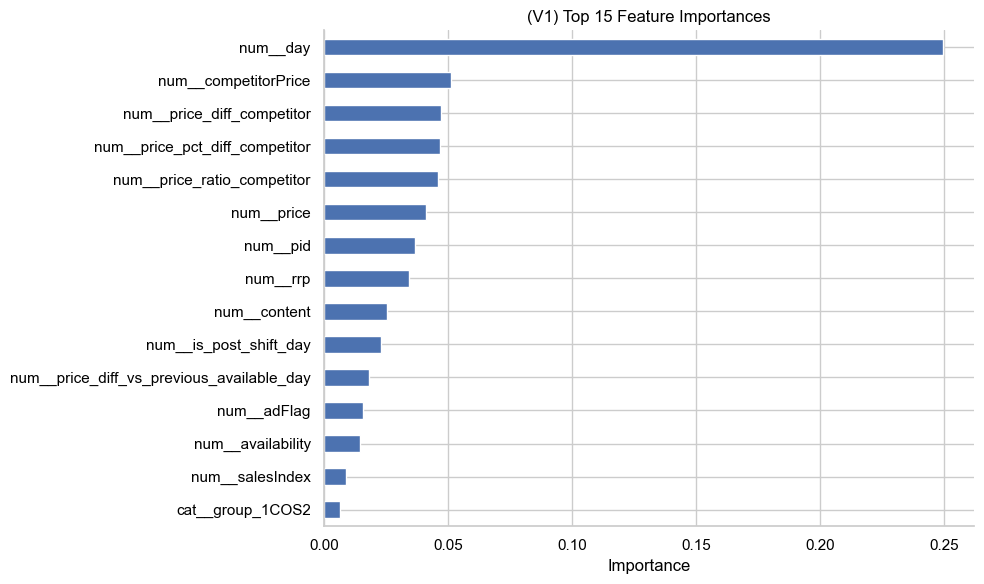

(V1) Top 15 Feature Importances:

  num__day                                      0.2497 (25.0%)
  num__competitorPrice                          0.0511 (5.1%)
  num__price_diff_competitor                    0.0470 (4.7%)
  num__price_pct_diff_competitor                0.0470 (4.7%)
  num__price_ratio_competitor                   0.0461 (4.6%)
  num__price                                    0.0411 (4.1%)
  num__pid                                      0.0367 (3.7%)
  num__rrp                                      0.0344 (3.4%)
  num__content                                  0.0253 (2.5%)
  num__is_post_shift_day                        0.0230 (2.3%)
  num__price_diff_vs_previous_available_day     0.0181 (1.8%)
  num__adFlag                                   0.0156 (1.6%)
  num__availability                             0.0146 (1.5%)
  num__salesIndex                               0.0089 (0.9%)
  cat__group_1COS2                              0.0066 (0.7%)


In [8]:
# Extract feature names from the pipeline preprocessor
feature_names = pipeline_v1.named_steps["preprocessor"].get_feature_names_out()

# Map importances to feature names and sort
importances_v1 = pd.Series(
    pipeline_v1.named_steps["model"].feature_importances_,
    index=feature_names
)
top_15_v1 = importances_v1.sort_values(ascending=False).head(15)

# Plot top 15 as horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
top_15_v1.sort_values().plot(kind="barh", ax=ax)
ax.set_title("(V1) Top 15 Feature Importances")
ax.set_xlabel("Importance")
sns.despine()
plt.tight_layout()
plt.show()


# Print top 15 with percentage values
print("(V1) Top 15 Feature Importances:\n")
for feature, importance in top_15_v1.items():
    print(f"  {feature:45s} {importance:.4f} ({importance * 100:.1f}%)")

### V1 Findings

At 25.3% importance, `day` absorbs roughly five times more than any other single feature.
This means the model is memorizing day-specific patterns ("day 45 had more orders") instead
of learning generalizable pricing and product signals. We already capture the meaningful
temporal information through `is_post_shift_day`, which sits at rank 10 with ~2.5%
importance. The raw `day` column is adding noise, not signal.

The four competitor price features (`competitorPrice`, `price_diff_competitor`,
`price_pct_diff_competitor`, `price_ratio_competitor`) occupy ranks 2 through 5 and
collectively consume ~20.5% of total importance. All four measure the same underlying
relationship on different scales. This redundancy dilutes each feature's contribution and
crowds out other signals.

Worth noting: `adFlag` (1.5%) and `availability` (1.3%) rank near the bottom despite
showing strong effects in our sample. Advertised products have a 32.1% order rate versus
22.6% for non-advertised (9.5 percentage point difference), and fully available products
(status 1) convert at 26.7% versus 0.1% for status 4. These features are likely suppressed
because `day` and the redundant price features dominate the importance budget.

**Next step:** Remove `day` and retrain as V2 to let `is_post_shift_day` and the
business-relevant features surface.

In [9]:
# V2 — Drop `day`. Train and evaluate again, and compare V1 and V2 evaluation metrics
COLUMNS_TO_DROP_V2 = ["day"]
features_train_v2 = features_train.drop(columns=COLUMNS_TO_DROP_V2)
features_test_v2 = features_test.drop(columns=COLUMNS_TO_DROP_V2)

# Build and train V2 pipeline without day
pipeline_v2 = build_pipeline(features_train_v2)
pipeline_v2.fit(features_train_v2, target_train)

# Predict on test set
predictions_v2 = pipeline_v2.predict(features_test_v2)
probabilities_v2 = pipeline_v2.predict_proba(features_test_v2)[:, 1]

# Compute evaluation metrics
accuracy_v2 = accuracy_score(target_test, predictions_v2)
precision_v2 = precision_score(target_test, predictions_v2)
recall_v2 = recall_score(target_test, predictions_v2)
f1_v2 = f1_score(target_test, predictions_v2)
roc_auc_v2 = roc_auc_score(target_test, probabilities_v2)

# Display results
print("Evaluation Metrics for Random Forest Classifier (V2, dropped day):\n")
print(f"  Accuracy:  {accuracy_v2:.4f}")
print(f"  Precision: {precision_v2:.4f}")
print(f"  Recall:    {recall_v2:.4f}")
print(f"  F1 Score:  {f1_v2:.4f}")
print(f"  ROC AUC:   {roc_auc_v2:.4f}")

# Compare V1 vs V2
print("\n\nV1 vs V2 Comparison:\n")
print(f"  {'Metric':<12} {'V1':>8} {'V2':>8} {'Change':>10}")
print(f"  {'Accuracy':<12} {accuracy_v1:>8.4f} {accuracy_v2:>8.4f} {accuracy_v2 - accuracy_v1:>+10.4f}")
print(f"  {'Precision':<12} {precision_v1:>8.4f} {precision_v2:>8.4f} {precision_v2 - precision_v1:>+10.4f}")
print(f"  {'Recall':<12} {recall_v1:>8.4f} {recall_v2:>8.4f} {recall_v2 - recall_v1:>+10.4f}")
print(f"  {'F1 Score':<12} {f1_v1:>8.4f} {f1_v2:>8.4f} {f1_v2 - f1_v1:>+10.4f}")
print(f"  {'ROC AUC':<12} {roc_auc_v1:>8.4f} {roc_auc_v2:>8.4f} {roc_auc_v2 - roc_auc_v1:>+10.4f}")

# Classification report
print(f"\nClassification Report:\n")
print(classification_report(target_test, predictions_v2, target_names=["Not Ordered", "Ordered"]))

Evaluation Metrics for Random Forest Classifier (V2, dropped day):

  Accuracy:  0.6617
  Precision: 0.3893
  Recall:    0.5670
  F1 Score:  0.4617
  ROC AUC:   0.6900


V1 vs V2 Comparison:

  Metric             V1       V2     Change
  Accuracy       0.6802   0.6617    -0.0185
  Precision      0.3981   0.3893    -0.0088
  Recall         0.4887   0.5670    +0.0784
  F1 Score       0.4388   0.4617    +0.0229
  ROC AUC        0.6808   0.6900    +0.0092

Classification Report:

              precision    recall  f1-score   support

 Not Ordered       0.82      0.69      0.75     29766
     Ordered       0.39      0.57      0.46     10234

    accuracy                           0.66     40000
   macro avg       0.61      0.63      0.61     40000
weighted avg       0.71      0.66      0.68     40000



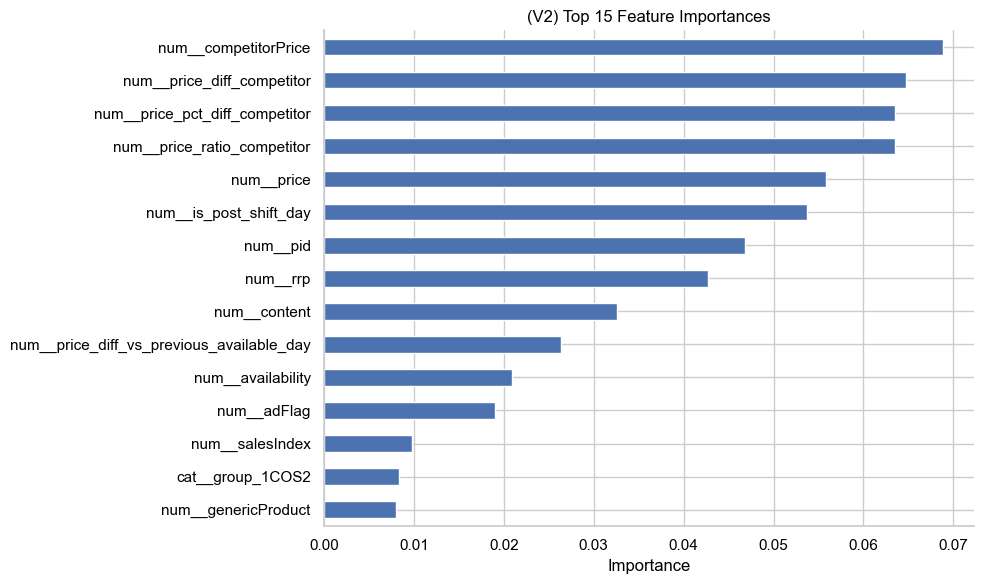

(V2) Top 15 Feature Importances:

  num__competitorPrice                          0.0689 (6.9%)
  num__price_diff_competitor                    0.0647 (6.5%)
  num__price_pct_diff_competitor                0.0635 (6.4%)
  num__price_ratio_competitor                   0.0635 (6.3%)
  num__price                                    0.0558 (5.6%)
  num__is_post_shift_day                        0.0537 (5.4%)
  num__pid                                      0.0469 (4.7%)
  num__rrp                                      0.0427 (4.3%)
  num__content                                  0.0326 (3.3%)
  num__price_diff_vs_previous_available_day     0.0264 (2.6%)
  num__availability                             0.0210 (2.1%)
  num__adFlag                                   0.0190 (1.9%)
  num__salesIndex                               0.0098 (1.0%)
  cat__group_1COS2                              0.0083 (0.8%)
  num__genericProduct                           0.0080 (0.8%)


In [10]:
# Extract feature names from the pipeline preprocessor
feature_names = pipeline_v2.named_steps["preprocessor"].get_feature_names_out()

# Map importances to feature names and sort
importances_v2 = pd.Series(
    pipeline_v2.named_steps["model"].feature_importances_,
    index=feature_names
)
top_15_v2 = importances_v2.sort_values(ascending=False).head(15)

# Plot top 15 as horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
top_15_v2.sort_values().plot(kind="barh", ax=ax)
ax.set_title("(V2) Top 15 Feature Importances")
ax.set_xlabel("Importance")
sns.despine()
plt.tight_layout()
plt.show()


# Print top 15 with percentage values
print("(V2) Top 15 Feature Importances:\n")
for feature, importance in top_15_v2.items():
    print(f"  {feature:45s} {importance:.4f} ({importance * 100:.1f}%)")

### V2 Findings

Removing `day` improved recall by 7.8 percentage points (from 48.9% to 56.7%) and ROC AUC
from 0.681 to 0.690. Accuracy dropped slightly from 0.680 to 0.662, which is a worthwhile
trade: the model now predicts "order" more aggressively, catching more real purchases at the
cost of some false positives. For a pharmacy optimizing pricing, missing a sale might be more
expensive than an unnecessary price adjustment.

`is_post_shift_day` climbed from rank 10 (2.5%) to rank 6 (5.4%), confirming that `day` was
previously absorbing temporal signal that this feature captures more cleanly. `availability`
and `adFlag` also gained visibility (2.1% and 1.9%, up from 1.3% and 1.5%).

The remaining problem is now obvious. The top four features (`competitorPrice`,
`price_diff_competitor`, `price_pct_diff_competitor`, `price_ratio_competitor`) collectively
hold 26.1% of importance while encoding the same relationship: how our price compares to the
competitor. Of these four, `price_ratio_competitor` is the most useful because it is
scale-independent (a €2 gap means different things for a €5 product versus a €50 product).

**Next step:** Drop `competitorPrice`, `price_diff_competitor`, and
`price_pct_diff_competitor`. Keep only `price_ratio_competitor` as the single competitor
signal, alongside `has_competitor` for rows with no competitor data.

In [11]:
# V3 — Drop redundant competitor price features, keep only price_ratio_competitor and has_competitor_price. Train and evaluate again, and compare V1, V2, and V3 evaluation metrics
COLUMNS_TO_DROP_V3 = ["day", "competitorPrice", "price_diff_competitor", "price_pct_diff_competitor"]
features_train_v3 = features_train.drop(columns=COLUMNS_TO_DROP_V3)
features_test_v3 = features_test.drop(columns=COLUMNS_TO_DROP_V3)

# Build and train V3 pipeline
pipeline_v3 = build_pipeline(features_train_v3)
pipeline_v3.fit(features_train_v3, target_train)

# Predict on test set
predictions_v3 = pipeline_v3.predict(features_test_v3)
probabilities_v3 = pipeline_v3.predict_proba(features_test_v3)[:, 1]

# Compute evaluation metrics
accuracy_v3 = accuracy_score(target_test, predictions_v3)
precision_v3 = precision_score(target_test, predictions_v3)
recall_v3 = recall_score(target_test, predictions_v3)
f1_v3 = f1_score(target_test, predictions_v3)
roc_auc_v3 = roc_auc_score(target_test, probabilities_v3)

# Display results
print("Evaluation Metrics for Random Forest Classifier (V3, dropped day + redundant price features):\n")
print(f"  Accuracy:  {accuracy_v3:.4f}")
print(f"  Precision: {precision_v3:.4f}")
print(f"  Recall:    {recall_v3:.4f}")
print(f"  F1 Score:  {f1_v3:.4f}")
print(f"  ROC AUC:   {roc_auc_v3:.4f}")

# Compare V1 vs V2 vs V3
print("\n\nV1 vs V2 vs V3 Comparison:\n")
print(f"  {'Metric':<12} {'V1':>8} {'V2':>8} {'V3':>8}")
print(f"  {'Accuracy':<12} {accuracy_v1:>8.4f} {accuracy_v2:>8.4f} {accuracy_v3:>8.4f}")
print(f"  {'Precision':<12} {precision_v1:>8.4f} {precision_v2:>8.4f} {precision_v3:>8.4f}")
print(f"  {'Recall':<12} {recall_v1:>8.4f} {recall_v2:>8.4f} {recall_v3:>8.4f}")
print(f"  {'F1 Score':<12} {f1_v1:>8.4f} {f1_v2:>8.4f} {f1_v3:>8.4f}")
print(f"  {'ROC AUC':<12} {roc_auc_v1:>8.4f} {roc_auc_v2:>8.4f} {roc_auc_v3:>8.4f}")

# Classification report
print(f"\nClassification Report:\n")
print(classification_report(target_test, predictions_v3, target_names=["Not Ordered", "Ordered"]))

Evaluation Metrics for Random Forest Classifier (V3, dropped day + redundant price features):

  Accuracy:  0.6585
  Precision: 0.3885
  Recall:    0.5831
  F1 Score:  0.4663
  ROC AUC:   0.6923


V1 vs V2 vs V3 Comparison:

  Metric             V1       V2       V3
  Accuracy       0.6802   0.6617   0.6585
  Precision      0.3981   0.3893   0.3885
  Recall         0.4887   0.5670   0.5831
  F1 Score       0.4388   0.4617   0.4663
  ROC AUC        0.6808   0.6900   0.6923

Classification Report:

              precision    recall  f1-score   support

 Not Ordered       0.83      0.68      0.75     29766
     Ordered       0.39      0.58      0.47     10234

    accuracy                           0.66     40000
   macro avg       0.61      0.63      0.61     40000
weighted avg       0.71      0.66      0.68     40000



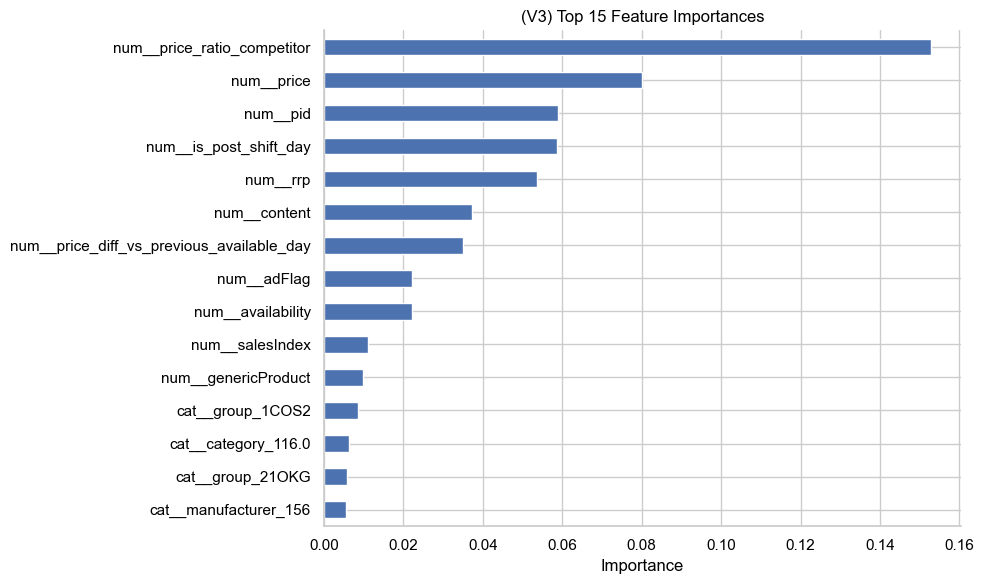

(V3) Top 15 Feature Importances:

  num__price_ratio_competitor                   0.1528 (15.3%)
  num__price                                    0.0800 (8.0%)
  num__pid                                      0.0590 (5.9%)
  num__is_post_shift_day                        0.0587 (5.9%)
  num__rrp                                      0.0536 (5.4%)
  num__content                                  0.0374 (3.7%)
  num__price_diff_vs_previous_available_day     0.0350 (3.5%)
  num__adFlag                                   0.0222 (2.2%)
  num__availability                             0.0221 (2.2%)
  num__salesIndex                               0.0111 (1.1%)
  num__genericProduct                           0.0099 (1.0%)
  cat__group_1COS2                              0.0084 (0.8%)
  cat__category_116.0                           0.0063 (0.6%)
  cat__group_21OKG                              0.0057 (0.6%)
  cat__manufacturer_156                         0.0056 (0.6%)


In [12]:
# Extract feature names from V3 pipeline
feature_names_v3 = pipeline_v3.named_steps["preprocessor"].get_feature_names_out()

# Map importances to feature names and sort
importances_v3 = pd.Series(
    pipeline_v3.named_steps["model"].feature_importances_,
    index=feature_names_v3
)
top_15_v3 = importances_v3.sort_values(ascending=False).head(15)

# Plot top 15 as horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))
top_15_v3.sort_values().plot(kind="barh", ax=ax)
ax.set_title("(V3) Top 15 Feature Importances")
ax.set_xlabel("Importance")
sns.despine()
plt.tight_layout()
plt.show()

# Print top 15 with percentage values
print("(V3) Top 15 Feature Importances:\n")
for feature, importance in top_15_v3.items():
    print(f"  {feature:45s} {importance:.4f} ({importance * 100:.1f}%)")

### V3 Findings

Dropping the three redundant competitor features produced another small gain: recall climbed
to 58.3% (from 56.7% in V2) and ROC AUC reached 0.692. The improvement is modest compared
to the V1 → V2 jump, which makes sense. Removing `day` eliminated a dominant noise source;
removing redundant features just cleaned up duplication.

The feature importance distribution is now much more interpretable. `price_ratio_competitor`
leads at 15.3%, consolidating the signal that was previously split across four columns.
`price` (8.0%), `pid` (5.9%), and `is_post_shift_day` (5.9%) follow, with no single feature
dominating the way `day` did in V1. This is what a healthy importance distribution looks
like: the model draws from multiple signals rather than over-relying on one.

Specific categorical values are now appearing in the bottom ranks (`group_1COS2`,
`category_116.0`, `manufacturer_156`). These were invisible in V1 and V2 because the
redundant features consumed the importance budget. Whether these specific categories carry
real business meaning or just reflect high-cardinality noise is worth investigating, but
their presence confirms that OneHotEncoder is letting the model access individual category
signals.

### Iteration Summary

| Version | Change                             | Recall | ROC AUC | Key Lesson                                                    |
|---------|------------------------------------|--------|---------|---------------------------------------------------------------|
| V1      | All features                       | 48.9%  | 0.681   | `day` dominated at 25.3%, suppressing everything else         |
| V2      | Dropped `day`                      | 56.7%  | 0.690   | Recall jumped 7.8 pp; redundant price features now visible    |
| V3      | Dropped 3 redundant price features | 58.3%  | 0.692   | Importance spreads evenly & model draws from multiple signals |

Feature selection mattered more than hyperparameter tuning at this stage. Each version
removed a specific problem identified by the previous version's feature importance analysis,
not by guessing. This is the iterative approach CRISP-DM describes: build, assess, refine.

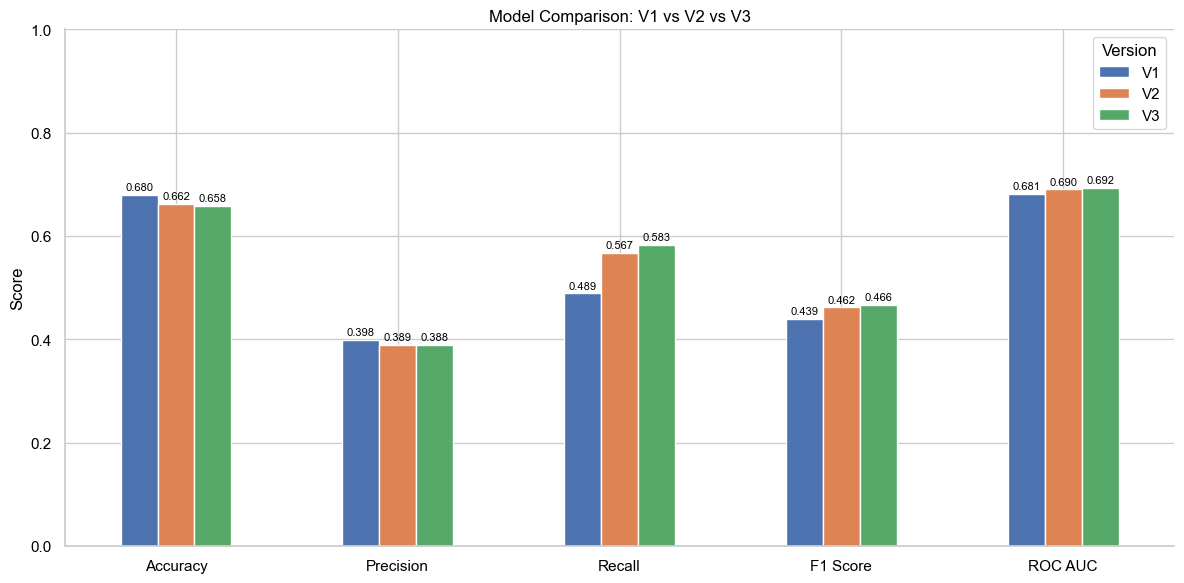

In [13]:
# Collect all metrics into a DataFrame for plotting
comparison_df = pd.DataFrame({
    "V1": [accuracy_v1, precision_v1, recall_v1, f1_v1, roc_auc_v1],
    "V2": [accuracy_v2, precision_v2, recall_v2, f1_v2, roc_auc_v2],
    "V3": [accuracy_v3, precision_v3, recall_v3, f1_v3, roc_auc_v3],
}, index=["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"])

# Plot grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6), facecolor="white")
comparison_df.plot(kind="bar", ax=ax, rot=0)

# Add value labels on each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2) # type: ignore

ax.set_title("Model Comparison: V1 vs V2 vs V3")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.legend(title="Version")
sns.despine()
plt.tight_layout()
plt.show()

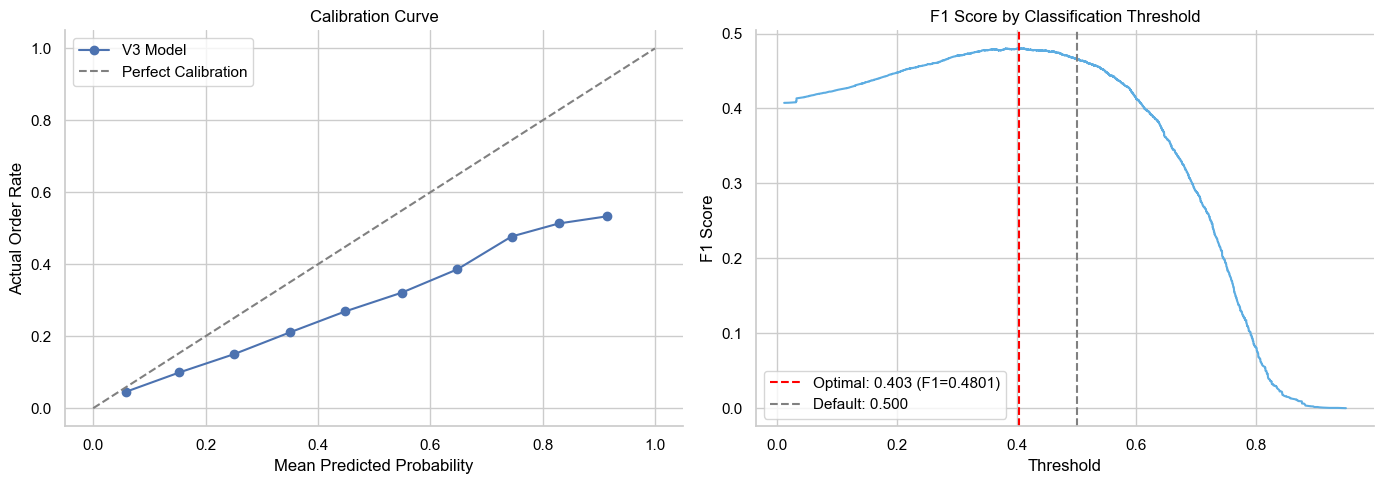

Optimal threshold: 0.403
F1 at optimal:     0.4801
F1 at default 0.5: 0.4663


In [14]:
# Compute calibration curve (predicted probability vs actual frequency)
prob_true, prob_pred = calibration_curve(target_test, probabilities_v3, n_bins=10)

# Compute F1 score across a range of thresholds
precision_curve, recall_curve, thresholds = precision_recall_curve(target_test, probabilities_v3)
f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-10)

# Find the threshold that maximizes F1
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

# Two-panel chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor="white")

# Left panel: calibration curve
ax1.plot(prob_pred, prob_true, marker="o", label="V3 Model")
ax1.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect Calibration")
ax1.set_title("Calibration Curve")
ax1.set_xlabel("Mean Predicted Probability")
ax1.set_ylabel("Actual Order Rate")
ax1.legend()
sns.despine(ax=ax1)

# Right panel: F1 by threshold
ax2.plot(thresholds, f1_scores[:-1], color="#5DADE2")
ax2.axvline(x=optimal_threshold, color="red", linestyle="--",
            label=f"Optimal: {optimal_threshold:.3f} (F1={optimal_f1:.4f})")
ax2.axvline(x=0.5, color="gray", linestyle="--", label="Default: 0.500")
ax2.set_title("F1 Score by Classification Threshold")
ax2.set_xlabel("Threshold")
ax2.set_ylabel("F1 Score")
ax2.legend()
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

# Print optimal threshold
print(f"Optimal threshold: {optimal_threshold:.3f}")
print(f"F1 at optimal:     {optimal_f1:.4f}")
print(f"F1 at default 0.5: {f1_v3:.4f}")

### Understanding the Calibration and Threshold Charts

**Calibration curve (left panel):** This chart checks whether the model's predicted
probabilities match reality. The x-axis shows what the model predicted (for example, "80%
chance of order") and the y-axis shows what actually happened (the real order rate for those
rows). If every point sits on the diagonal, the model's confidence is perfectly accurate.

Our model tracks the diagonal well up to about 0.4 predicted probability, then drifts below
it. At 0.8 predicted probability, the actual order rate is only about 53%. The model is
overconfident at high probabilities.

**F1 by threshold (right panel):** The default classification threshold is 0.5, meaning any
row with a predicted probability above 50% is classified as "order." But 0.5 is not
necessarily optimal. This chart sweeps across all possible thresholds and computes the F1
score at each one.

F1 peaks at a threshold of 0.403, where it reaches 0.4801 (compared to 0.4663 at the
default 0.5). Lowering the threshold from 0.5 to 0.403 means the model also flags rows with
40 to 50% predicted probability as orders. This catches more real purchases but introduces
some additional false positives. Whether that trade-off is worthwhile depends on the business
cost of each error type, which we address in the next section.

In [15]:
# Generate predictions at the optimal threshold
predictions_optimized = (probabilities_v3 >= optimal_threshold).astype(int)

# Compute metrics at both thresholds
precision_default = precision_score(target_test, predictions_v3)
recall_default = recall_score(target_test, predictions_v3)
f1_default = f1_score(target_test, predictions_v3)

precision_optimized = precision_score(target_test, predictions_optimized)
recall_optimized = recall_score(target_test, predictions_optimized)
f1_optimized = f1_score(target_test, predictions_optimized)

# Display comparison table
print(f"Threshold Comparison (V3):\n")
print(f"  {'Metric':<12} {'Default 0.5':>14} {'Optimized ' + f'{optimal_threshold:.3f}':>14} {'Change':>10}")
print(f"  {'Precision':<12} {precision_default:>14.4f} {precision_optimized:>14.4f} {precision_optimized - precision_default:>+10.4f}")
print(f"  {'Recall':<12} {recall_default:>14.4f} {recall_optimized:>14.4f} {recall_optimized - recall_default:>+10.4f}")
print(f"  {'F1 Score':<12} {f1_default:>14.4f} {f1_optimized:>14.4f} {f1_optimized - f1_default:>+10.4f}")

# Calculate how many additional rows are flagged at the lower threshold
additional_flagged = predictions_optimized.sum() - predictions_v3.sum()
additional_true_orders = (
    ((predictions_optimized == 1) & (target_test == 1)).sum()
    - ((predictions_v3 == 1) & (target_test == 1)).sum()
)
additional_false_positives = additional_flagged - additional_true_orders

print(f"\n\nBusiness Impact (per {len(target_test):,} test rows):\n")
print(f"  Additional rows flagged as orders: {additional_flagged:,}")
print(f"  Of those, actual orders caught:    {additional_true_orders:,}")
print(f"  Additional false positives:        {additional_false_positives:,}")

Threshold Comparison (V3):

  Metric          Default 0.5 Optimized 0.403     Change
  Precision            0.3885         0.3572    -0.0313
  Recall               0.5831         0.7322    +0.1491
  F1 Score             0.4663         0.4801    +0.0139


Business Impact (per 40,000 test rows):

  Additional rows flagged as orders: 5,618
  Of those, actual orders caught:    1,526
  Additional false positives:        4,092


### Business Interpretation

Lowering the threshold from 0.500 to 0.403 catches 1,526 additional real orders out of
10,234 in the test set, increasing recall from 58.3% to 73.2%. The cost is 4,092 additional
false positives, where the model predicts a purchase that does not happen.

This trade-off favors the lower threshold for a simple reason: the two error types are not
equally expensive. A missed order is lost revenue the pharmacy cannot recover. A false
positive might trigger an unnecessary price adjustment, but the pricing engine recalculates
daily, so the correction happens automatically the next day.

In concrete terms: per 40,000 interactions, moving to the optimized threshold recovers 1,526
sales at the cost of 4,092 temporary pricing adjustments. Precision drops modestly from
38.9% to 35.7%. For a business where dynamic pricing already changes daily, that temporary
noise is a small price to pay for catching 14.9 percentage points more actual purchases.Thus, recall
went from 58.3% to 73.2%. The difference (14.9 percentage points) is the gain. This is what the
pharmacy gets in return for accepting those extra false positives.